In [ ]:
# DATA PREPARATION

import pandas as pd

df = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

cols_to_convert = [
    "Diabetes_binary", "HighBP", "HighChol", "Smoker", "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump", "Stroke", "HeartDiseaseorAttack", "GenHlth", "DiffWalk", "Sex", "CholCheck", "AnyHealthcare", "NoDocbcCost"
]
df[cols_to_convert] = df[cols_to_convert].astype("int8")

cols_to_convert_2 = [
    "BMI", "MentHlth", "PhysHlth", "Age", "Education", "Income"
]
df[cols_to_convert_2] = df[cols_to_convert_2].astype("int64")
print("\n", df.columns)
print("\nNumber of Rows and Columns:", df.shape)


 Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

Number of Rows and Columns: (70692, 22)


Text(0.5, 0, 'Risk Factors')

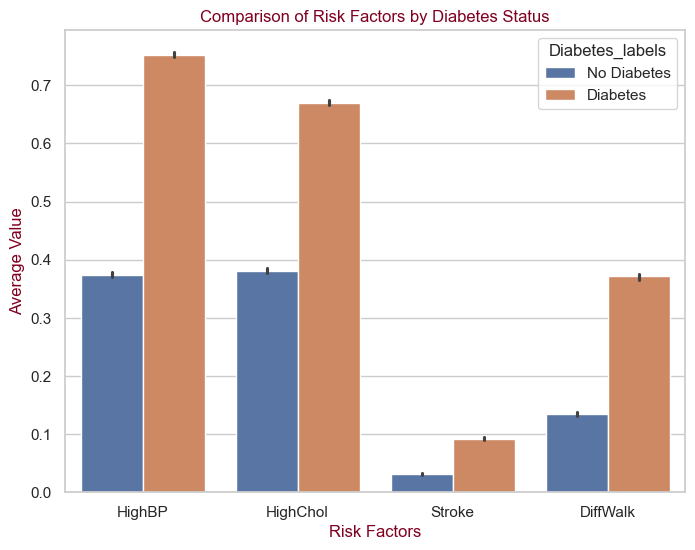

In [34]:
# Comparsion of Risk Factors by Diabetes Status Graph

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="deep")

risk_factors = [
    'HighBP', 'HighChol', 'Stroke', 'DiffWalk'
]
df_melted = df.melt( # Birden fazla sütunu tek sütun altında toplar, birden fazla değişkeni tek grafikte karşılaştırır
    id_vars="Diabetes_binary", # Sabit kalacak sütun
    value_vars = risk_factors # Eritilecek (tek sütunda toplanacak) sütunlar
)
df_melted["Diabetes_labels"] = df_melted["Diabetes_binary"].map( # pandas metodu, değerleri başka değerlere dönüştürür
    {
        0: "No Diabetes",
        1: "Diabetes"
    }
)
plt.figure(figsize=(8, 6))
sns.barplot(
    data=df_melted,
    x="variable",
    y="value",
    hue="Diabetes_labels"
)
plt.title("Comparison of Risk Factors by Diabetes Status", color='#800020')
plt.ylabel("Average Value", color='#800020')
plt.xlabel("Risk Factors", color='#800020')

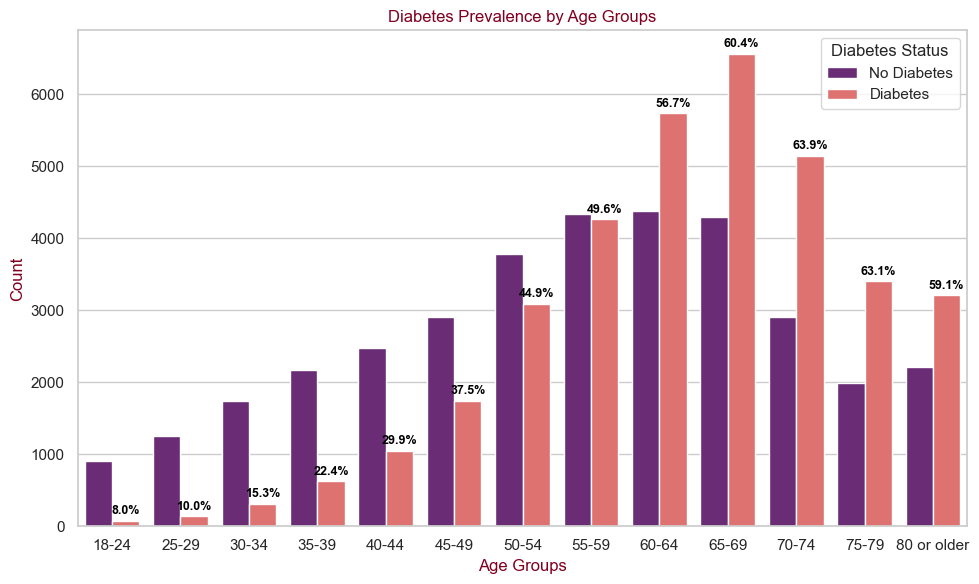

In [ ]:
# Diabetes Prevalence by Age Groups Graph

import warnings
warnings.filterwarnings("ignore")

age_labels = {
    1: "18-24",
    2: "25-29",
    3: "30-34",
    4: "35-39",
    5: "40-44",
    6: "45-49",
    7: "50-54",
    8: "55-59",
    9: "60-64",
    10: "65-69",
    11: "70-74",
    12: "75-79",
    13: "80 or older"
}

# ham veriden her yaş grubu için diyabetin görülme oranını hesaplar
age_prevalence = df.groupby("Age")["Diabetes_binary"].mean().multiply(100) 

plt.figure(figsize=(10, 6))

ax = sns.countplot( # veriyi otomatik sayar ve çubuk grafik oluşturur / Kategorik Veriler İçin İdeal
    data=df,
    x="Age",
    hue="Diabetes_binary",
    hue_order=[0, 1],
    palette="magma"
)

ax.legend(
    title="Diabetes Status",
    labels=["No Diabetes", "Diabetes"]
)

ax.set_xticklabels( # X ekseninde yazan metin nesnelerini (1, 2, ... 13) bir liste olarak çeker
    [
        age_labels[ # Bu sayıyı sözlükte arar ve karşılığını bulur (1 -> "18-24")
            int( # Bu metni sayıya çevirir (1)
                tick.get_text() # Ekranda yazan metni (örneğin "1") alır
            )
        ] for tick in ax.get_xticklabels()
    ]
)

for i, bar in enumerate(ax.containers[1]): # containers[1] turuncu barların üzerine yazı yazmak için 
    height = bar.get_height() # Barın yüksekliğini alır
    prevalence = age_prevalence.loc[i + 1]
    ax.text(
        bar.get_x() + bar.get_width() / 2, # Yazıyı yatayda barın tam ortasına hizalar
        height + 50, # Barın biraz üzerinde görünmesi için küçük bir ofset
        f"{prevalence:.1f}%", # Diyabet prevalansını yüzde formatında yazdırır
        ha="center", 
        va="bottom", 
        fontsize=9, 
        fontweight="bold", 
        color="black"
    )

plt.title("Diabetes Prevalence by Age Groups", color='#800020')
plt.xlabel("Age Groups", color='#800020')   
plt.ylabel("Count", color='#800020')
plt.tight_layout()